In [107]:
# Cargar librerias necesarias.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import TTestIndPower


In [121]:
df= pd.read_csv('Anexo 1 - Base de Datos dynamic_pricing (3).csv')
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [109]:
# limpiar los datos
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [110]:
print(df.shape)
df.describe()

(1000, 10)


,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


### Paso 2.1 TCL

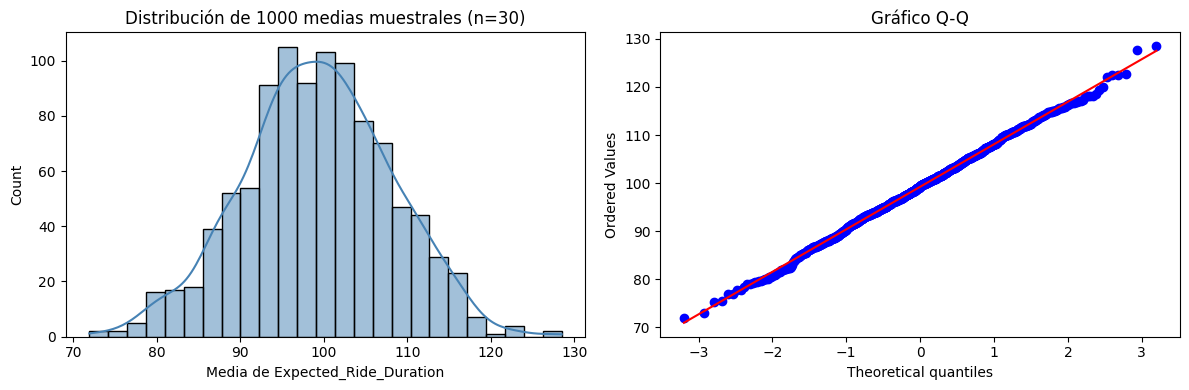

In [111]:

np.random.seed(0)
poblation = df['Expected_Ride_Duration'].values
n,reps = 30, 1000

medias_muestrales = np.array([np.mean(np.random.choice(poblation, n, replace=True)) for i in range(reps)])


# Distribución de las medias muestrales
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(medias_muestrales, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Distribución de 1000 medias muestrales (n=30)')
ax[0].set_xlabel('Media de Expected_Ride_Duration')
stats.probplot(medias_muestrales, dist="norm", plot=ax[1])
ax[1].set_title('Gráfico Q-Q')
plt.tight_layout()
plt.show()

In [112]:
print("Media poblacional          :", poblation.mean().round(2))
print("Media de las medias        :", medias_muestrales.mean().round(2))
print("Desv. est. poblacional     :", poblation.std(ddof=1).round(2))
print("Error estándar teórico     :", (poblation.std(ddof=1)/np.sqrt(n)).round(2))
print("Desv. est. de las medias   :", medias_muestrales.std(ddof=1).round(2))
print("Shapiro-Wilk p-valor       :", stats.shapiro(medias_muestrales)[1].round(4))

Media poblacional          : 99.59
Media de las medias        : 99.22
Desv. est. poblacional     : 49.17
Error estándar teórico     : 8.98
Desv. est. de las medias   : 8.84
Shapiro-Wilk p-valor       : 0.7475


Evidencia del histograma (lado izquierdo): Se observa que, a pesar de que los datos originales de la población (Expected_Ride_Duration) pueden presentar sesgos o distribuciones asimétricas, el histograma de las 1,000 medias muestrales adquiere una forma de campana (simétrica y centrada), lo cual es consistente con el Teorema Central del Límite y aporta evidencia visual a favor de la aproximación a la normalidad de la distribución de las medias muestrales.

Evidencia del gráfico Q-Q (lado derecho): Los puntos azules de las medias muestrales siguen de manera ajustada la línea recta diagonal roja de referencia. Esto es consistente, de forma gráfica, con el supuesto de normalidad de las medias muestrales; sin embargo, este análisis visual no constituye una confirmación matemática absoluta de la normalidad, sino que debe complementarse con la prueba formal de Shapiro-Wilk presentada a continuación, cuyos resultados no permitieron rechazar la hipótesis de normalidad.

### Paso 2.2

In [113]:

# IC 95% para la MEDIA de Expected_Ride_Duration
x = df['Expected_Ride_Duration']
n = len(x); media = x.mean(); s = x.std(ddof=1)
ic_media = stats.t.interval(0.95, df=n-1, loc=media, scale=s/np.sqrt(n))

print(f"IC 95% media duración: [{ic_media[0]:.2f} , {ic_media[1]:.2f}] minutos")

IC 95% media duración: [96.54 , 102.64] minutos


Con un 95 % de nivel de confianza, el promedio de la duración esperada de los viajes en la población se encontraría entre 96.54 y 102.64 minutos (aproximadamente entre 1 hora y 36 minutos y 1 hora y 43 minutos).

Utilidad para la Toma de Decisiones:

Planificación operativa y asignación de flota: El intervalo permite estimar los tiempos de ciclo y la disponibilidad de los vehículos con una holgura de hasta ~103 minutos por trayecto, lo que puede resultar útil como insumo para la planificación de turnos y la asignación de recursos.

Promesas de servicio (SLA): El intervalo puede servir de referencia para establecer ventanas de tiempo de entrega o llegada realistas para los clientes, ayudando a evitar penalizaciones o falsas expectativas. No obstante, estas ventanas deberían validarse con análisis adicionales que consideren otras variables operativas, ya que este intervalo se refiere exclusivamente a la duración esperada del viaje.

Gestión de tarifas e incentivos: El intervalo puede orientar el diseño de compensaciones a los conductores en función de bloques de tiempo operativos delimitados, siempre que se complemente con información sobre otras variables relevantes para la operación.

In [114]:
# IC del 95% para la proporción de Average_Ratings excelente(≥4.0).
y = (df['Average_Ratings'] >= 4.0).astype(int)
# p = número de éxitos, n = tamaño de la muestra
p=y.sum(); n = len(y)
ic_proporcion = proportion_confint(p, n, alpha=0.05, method='normal')

print(f"IC 95% proporción: [{ic_proporcion[0]:.4f} , {ic_proporcion[1]:.4f}]")

IC 95% proporción: [0.6572 , 0.7148]


Con un 95 % de confianza, la proporción de viajes o servicios que reciben una calificación excelente (≥ 4.0) dentro de la población general se encontraría entre el 65.72 % y el 71.48 %.

Utilidad para la Toma de Decisiones:

Control de calidad e indicadores clave (KPIs): Si la meta de satisfacción de la empresa es, por ejemplo, alcanzar un 75 % o un 80 % de excelencia, este resultado sugiere que, con un 95 % de confianza, el nivel actual de excelencia se encontraría por debajo del objetivo, lo que orienta la conveniencia de evaluar acciones correctivas. Es importante señalar que este intervalo se refiere exclusivamente a la proporción de calificaciones excelentes y no permite identificar las causas específicas de la brecha observada.

Estrategias de retención de clientes: El intervalo es consistente con que entre un 28.5 % y un 34.3 % de los usuarios reciban una experiencia aceptable o deficiente (< 4.0), lo que podría señalar un margen para evaluar programas de fidelización o revisión de rutas y conductores. Esta interpretación se plantea como una recomendación exploratoria a partir del intervalo obtenido, ya que el análisis no permite establecer relaciones causales ni identificar los factores específicos asociados a la experiencia del usuario.

In [115]:
# IC 95% para la VARIANZA de Historical_Cost_of_Ride
c = df['Historical_Cost_of_Ride']
n = len(c); s2 = c.var(ddof=1)
gl = n - 1
ic_var = ((gl*s2)/stats.chi2.ppf(0.975, gl), (gl*s2)/stats.chi2.ppf(0.025, gl))

print(f"Varianza muestral costo: {s2:,.2f}")
print(f"IC 95% varianza costo  : [{ic_var[0]:,.2f} , {ic_var[1]:,.2f}]")
print(f"IC 95% desv. est. costo: [{np.sqrt(ic_var[0]):.2f} , {np.sqrt(ic_var[1]):.2f}]")

Varianza muestral costo: 35,028.40
IC 95% varianza costo  : [32,148.63 , 38,315.27]
IC 95% desv. est. costo: [179.30 , 195.74]


Con un 95 % de confianza, la variabilidad típica o dispersión alrededor del costo promedio de un viaje se encontraría entre 179.30 y 195.74 unidades monetarias.

Utilidad para la Toma de Decisiones:

Análisis de riesgo financiero e ingresos: Una desviación estándar de hasta 195.74 unidades monetarias es consistente con una elevada variabilidad en el costo de los trayectos. Para las finanzas de la empresa o para la previsibilidad del usuario, esta magnitud de fluctuación podría motivar la evaluación de alternativas como tarifas planas o límites en tarifas dinámicas. Esta interpretación se plantea como una recomendación exploratoria a partir del intervalo obtenido, ya que el análisis no permite establecer relaciones causales ni identificar los factores específicos que originan dicha variabilidad.

Detección de valores atípicos (outliers) o cobros inconsistentes: La amplitud del intervalo es compatible con la posible coexistencia de trayectos con costos muy dispares; sin embargo, este análisis no permite identificar las causas específicas de dicha dispersión (como rutas cortas frente a rutas largas o picos de demanda), ya que dichas variables no fueron incluidas en el contraste. Como recomendación para futuros análisis, podría explorarse la segmentación de la oferta en distintas categorías de viaje (urbano, intermunicipal, premium) con el fin de estudiar si dicha segmentación contribuye a reducir la variabilidad interna por grupo, sin que ello constituya una conclusión derivada directamente de este resultado.

### Paso 2.3 Pruebas de Hipótesis para Comparación de Grupos 

##### 2.3.1 Prueba de hipotesis para medias
 "La duración promedio de los viajes no cambia entre los 'Customer_Loyalty_Status".

    H0: las duracion promedio de los viajes no varia segun el status de lealtad del cliente
    H1: las duracion promedio de los viajes varian segun el status de lealtad del cliente

In [116]:
# separar los datos por estado de lealtad del cliente

regular = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']
gold = df[df['Customer_Loyalty_Status'] == 'Gold']['Expected_Ride_Duration']

print("n Regular:", len(regular), "| media:", round(regular.mean(),2), "| sd:", round(regular.std(ddof=1),2))
print("n Gold   :", len(gold), "| media:", round(gold.mean(),2), "| sd:", round(gold.std(ddof=1),2))
print('-------------------------------')

# Pureba de levvene para igualdad de varianzas

stat, p_value = stats.levene(regular, gold)
alfa = 0.05
print(f"Prueba de Levene: estadístico={stat:.4f}, p-valor={p_value:.4f}")
if p_value < alfa:
    print("Se rechaza H0: Las varianzas son diferentes.")
else:
    print("No se rechaza H0: Las varianzas son iguales.")
print('-------------------------------')

var = p_value >= alfa

# Prueba t de Student para igualdad de medias

result = stats.ttest_ind(regular, gold, equal_var=var)
print(f"P_value de la prueba t: {result.pvalue:.4f}")
print(f"Estadístico t: {result.statistic:.4f}")
print('-------------------------------')

# Comparar con el nivel de significancia
if result.pvalue < alfa:
    print("Se rechaza H0: Las medias son diferentes.")
else:
    print("No se rechaza H0: Las medias son iguales.")

n Regular: 320 | media: 100.57 | sd: 49.34
n Gold   : 313 | media: 101.6 | sd: 50.17
-------------------------------
Prueba de Levene: estadístico=0.0144, p-valor=0.9044
No se rechaza H0: Las varianzas son iguales.
-------------------------------
P_value de la prueba t: 0.7930
Estadístico t: -0.2625
-------------------------------
No se rechaza H0: Las medias son iguales.


Conclusión: No se encontró evidencia estadística significativa para afirmar que la duración esperada del viaje (Expected_Ride_Duration) sea diferente entre los clientes con estatus de lealtad Regular y Gold.

En otras palabras, con los datos analizados no es posible concluir que el nivel de lealtad del cliente (Regular vs. Gold) esté asociado a una diferencia en la duración estimada de sus viajes. Si bien los segmentos presentan comportamientos similares en esta métrica según la muestra observada, este resultado no permite descartar la posible influencia de otras variables no incluidas en el contraste, ni constituye una confirmación absoluta de que ambos grupos sean equivalentes en la población.

##### 2.3.2 Prueba de hipotesis para proporciones
 "Prueba Z para la diferencia de dos proporciones de calificaciones excelentes ($\ge 4.0$) según el tipo de vehículo (Economy vs. Premium)"

      H0: No hay diferencia en la proporcion de calificacion segun el tipo de vehiculo
      H1: Existe una diferencia en la proporcion de calificacion segun el tipo de vehiculo

In [117]:
# separar los datos por estado de lealtad del cliente

# Crear la variable binaria (1 si es excelente, 0 si no)
df['Excelente'] = (df['Average_Ratings'] >= 4.0).astype(int)

Economy = df[df['Vehicle_Type'] == 'Economy']['Excelente']
Premium = df[df['Vehicle_Type'] == 'Premium']['Excelente']

exitos = np.array([Economy.sum(), Premium.sum()])
viajes = np.array([len(Economy), len(Premium)])


print(f"Economy: {exitos[0]}/ {len(Economy)} = {Economy.mean():.4f} éxitos de {len(Economy)} viajes")
print(f"Premium: {exitos[1]}/ {len(Premium)} = {Premium.mean():.4f} éxitos de {len(Premium)} viajes")
print('--------------------------------')

z_stat, p_value = proportions_ztest(exitos, viajes, alternative='two-sided')
print(f"estadístico z: {z_stat:.4f}, p-valor: {p_value:.4f}")
print('--------------------------------')

alpha = 0.05
if p_value < alpha:
    print(f"Se rechaza H0: Las proporciones son diferentes (p-valor={p_value:.4f})")
else:
    print(f"No se rechaza H0: Las proporciones son iguales (p-valor={p_value:.4f})")

Economy: 333/ 478 = 0.6967 éxitos de 478 viajes
Premium: 353/ 522 = 0.6762 éxitos de 522 viajes
--------------------------------
estadístico z: 0.6946, p-valor: 0.4873
--------------------------------
No se rechaza H0: Las proporciones son iguales (p-valor=0.4873)


Dado que el p-valor (p = 0.4873) es mayor que el nivel de significancia prefijado (α = 0.05), no se rechaza la hipótesis nula (H₀).

Conclusión: Con un nivel de confianza del 95 %, no se encontró evidencia estadística suficiente para afirmar que exista una diferencia en la proporción de calificaciones excelentes (≥ 4.0) entre los vehículos de tipo Economy (69.67 %) y Premium (67.62 %). Este resultado sugiere que, con los datos disponibles, el tipo de vehículo no muestra una asociación estadísticamente significativa con la proporción de calificaciones excelentes; sin embargo, este contraste no permite identificar qué otras variables podrían estar influyendo en la calificación del servicio, ya que no fueron incluidas en el análisis.

### Paso 2.4 Pruebas de Varianza (F de Fisher) 

"Prueba F de Fisher para comparar la variabilidad de la duración esperada del viaje (Expected_Ride_Duration) según el estado de lealtad del cliente (Regular vs. Gold)"
            
        H0: No hay diferencia en la varianza de la duración del viaje según el estado de lealtad
        H1: Existe una diferencia en la varianza de la duración del viaje según el estado de lealtad

In [118]:
# calcular las varianzas muestrales de cada grupo, (ddof es el grado de libertad, ddof=1 para varianza muestral)
s1 = regular.var(ddof=1)
s2 = gold.var(ddof=1)

# Calcular los grados de libertad
gl1 = len(regular) - 1
gl2 = len(gold) - 1

# Calcular la estadística F
# Colocar la varianza mayor en el numerador para garantizar F >= 1
if s1 >= s2:
    F, df_num, df_den = s1/s2, gl1, gl2
else:
    F, df_num, df_den = s2/s1, gl2, gl1

# p-valor bilateral de la prueba F 
p_una_cola = stats.f.sf(F, df_num, df_den)
p_F = min(1.0, 2 * p_una_cola)

print(f"Varianza Regular = {s1:,.2f}")
print(f"Varianza Gold    = {s2:,.2f}")
print(f"F = {F:.4f} | gl = ({df_num},{df_den}) | p-valor = {p_F:.4f}")
print("Levene  p =", round(stats.levene(regular, gold).pvalue, 4))
print("Bartlett p =", round(stats.bartlett(regular, gold).pvalue, 4))
print('--------------------------------')

alpha = 0.05
if p_F < alpha:
    print(f"Se rechaza H0: Las varianzas son diferentes (p-valor={p_F:.4f})")
else:
    print(f"No se rechaza H0: Las varianzas son iguales (p-valor={p_F:.4f})")

Varianza Regular = 2,434.85
Varianza Gold    = 2,516.82
F = 1.0337 | gl = (312,319) | p-valor = 0.7686
Levene  p = 0.9044
Bartlett p = 0.3935
--------------------------------
No se rechaza H0: Las varianzas son iguales (p-valor=0.7686)


La aplicación de la prueba F de Fisher se justifica para evaluar si existe homocedasticidad (igualdad de varianzas) en la duración esperada del viaje entre los clientes Regular y Gold. Debido a que la prueba F es sumamente sensible a desviaciones de la normalidad, la inclusión de pruebas complementarias como las de Bartlett y Levene permite verificar la consistencia de este supuesto de homocedasticidad aun si existiera un ligero sesgo en la distribución de los tiempos de viaje, sin que ello implique una confirmación absoluta del supuesto, sino únicamente la ausencia de evidencia suficiente en contra del mismo en los datos analizados. Es importante señalar que estos resultados se refieren exclusivamente al contraste de igualdad de varianzas entre los grupos analizados y no permiten descartar la posible influencia de otras variables no incluidas en el análisis.

### Paso 2.5 Pruebas de Chi-Cuadrado 

"Prueba Chi-Cuadrado para evaluar la asociación entre el estado de lealtad del cliente (Customer_Loyalty_Status) y el tipo de vehículo (Vehicle_Type)"
            
        H0: Las variables son independientes (no hay asociación entre el estado de lealtad del cliente y el tipo de vehículo elegido).
        H1: Las variables no son independientes (existe una asociación entre el estado de lealtad del cliente y el tipo de vehículo elegido).

In [119]:
tabla =pd.crosstab(df['Customer_Loyalty_Status'], df['Vehicle_Type'])
print(tabla)
print('--------------------------------')

chi2_stat, p_value, gl, expected = stats.chi2_contingency(tabla, correction=False)
print(f"Chi-cuadrado = {chi2_stat:.4f} | gl = {gl} | p-valor = {p_value:.4f}")
print('--------------------------------')

alpha = 0.05
if p_value < alpha:
    print(f"Se rechaza H0: Las variables son dependientes (p-valor={p_value:.4f})")
else:
    print(f"No se rechaza H0: Las variables son independientes (p-valor={p_value:.4f})")

Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                         153      160
Regular                      144      176
Silver                       181      186
--------------------------------
Chi-cuadrado = 1.4916 | gl = 2 | p-valor = 0.4744
--------------------------------
No se rechaza H0: Las variables son independientes (p-valor=0.4744)


Dado que el p-valor (p = 0.4744) es ampliamente superior al nivel de significancia prefijado (α = 0.05), no se rechaza la hipótesis nula (H₀). La pequeña discrepancia en la distribución de viajes (por ejemplo, el 55.00 % de los clientes Regular que eligen Premium frente al 51.12 % de los clientes Gold) es compatible con la variabilidad aleatoria del muestreo bajo la hipótesis de independencia; sin embargo, este resultado no permite descartar que otras variables no analizadas puedan estar asociadas con la elección del vehículo, ni constituye una confirmación absoluta de que la única causa de dichas diferencias sea el azar.

### Paso 2.6 Análisis de Poder Estadístico y Errores Tipo I y I

In [120]:
# Separar los datos por estado de lealtad del cliente
n1= len(regular)
n2= len(gold)

# Calcular la desviación estándar combinada
sp = np.sqrt(((n1-1)*regular.var(ddof=1) + (n2-1)*gold.var(ddof=1)) / (n1+n2-2))

# Calcular la estadística d de Cohen
d = (regular.mean() - gold.mean()) / sp 
print(f"Tamaño del efecto (d de Cohen) = {d:.4f}")
print('--------------------------------')

# Calcular el poder estadístico (1-β) para la prueba t de Student
analisis = TTestIndPower()
poder = analisis.power(effect_size=abs(d), nobs1=n1, alpha=0.05, ratio=n2/n1, alternative='two-sided')
print(f"Poder estadístico (1-β) = {poder:.4f}")
print('--------------------------------')

# Calcular el tamaño de muestra requerido para lograr un poder estadístico de 0.80
n_req = analisis.solve_power(effect_size=abs(d), power=0.8, alpha=0.05, ratio=n2/n1, alternative='two-sided')
print(f"n requerido por grupo para 1-β=0.80 : {np.ceil(n_req):,.0f}")
print(f"n requerido total : {np.ceil(n_req)*2:,.0f}")

Tamaño del efecto (d de Cohen) = -0.0209
--------------------------------
Poder estadístico (1-β) = 0.0579
--------------------------------
n requerido por grupo para 1-β=0.80 : 36,455
n requerido total : 72,910


Según las convenciones de Cohen (0.2 pequeño, 0.5 mediano, 0.8 grande), un valor de 0.0209 representa un efecto nulo o despreciable. En términos prácticos, el tamaño del efecto estimado sugiere que la duración promedio esperada del viaje entre clientes Regular y Gold sería prácticamente idéntica si existiera una diferencia real de esa magnitud; sin embargo, este resultado no permite afirmar que ambos grupos sean equivalentes en la población, ya que el contraste no encontró diferencias estadísticamente significativas.

El poder estadístico es de tan solo 5.79 %, que está prácticamente al mismo nivel que α = 0.05. Esto no indica un mal diseño muestral, sino que el tamaño del efecto estimado entre los grupos es de magnitud despreciable, de modo que el tamaño de muestra actual (n₁ = 320, n₂ = 313) no tendría la sensibilidad suficiente para detectar un efecto de esa magnitud como estadísticamente significativo, aun si existiera.

Para lograr detectar estadísticamente un efecto de magnitud tan pequeña (d = 0.0209) con un poder del 80 %, se necesitaría recolectar casi 73,000 observaciones. Desde el punto de vista organizacional, estos resultados no permiten justificar una ampliación del tamaño de muestra, ya que el esfuerzo y los recursos requeridos no se corresponderían con una relevancia operativa significativa. Esta interpretación se plantea como una recomendación a partir del análisis de poder y no como una conclusión derivada directamente del contraste.

Error Tipo I (α = 5 %): rechazar H₀ cuando en realidad es verdadera → concluir erróneamente que Regular y Gold tienen duraciones distintas y reasignar recursos de flota innecesariamente, generando costos operativos sin beneficio.

Error Tipo II (β ≈ 94.21 %): no rechazar H₀ cuando es falsa → el poder es bajo, pero el impacto práctico de este error es limitado en este caso porque el tamaño del efecto estimado es de magnitud despreciable. Esto sugiere que, incluso si existiera una diferencia real de ≈1 minuto, su relevancia operativa sería mínima, sin que ello implique descartar la posible influencia de otras variables no incluidas en el contraste.

El análisis confirma que no se requiere ampliar el tamaño de la muestra. Aunque el poder de la prueba es bajo ($5.79\%$), esto se debe a que la diferencia entre las medias de ambos grupos de lealtad es prácticamente inexistente ($d = -0.0209$). Intentar recolectar más de 72,000 registros para encontrar significancia estadística en una diferencia tan minúscula representaría un esfuerzo ineficiente sin ningún retorno de inversión operacional.